In [55]:
import ndlib.models.ModelConfig as mc
import ndlib.models.epidemics as ep
from ndlib.utils import multi_runs
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import time # TODO: remove when done

## 2.1 Implement SIR and Simulate

Implement SIR disease spread on the network. Think about your experimental design
and which parameters of the model you will want to vary. Design code that will allow
you run multiple simulations while varying the disease parameter.

### Functions to generate network, model, and run SIR simulations

In [5]:
def create_network(network_type, num_nodes, seed = None, p = 0.01, m = 5, k = 6):
    if network_type == 'Erdos-Renyi':
        return nx.erdos_renyi_graph(num_nodes, p, seed)
    elif network_type == 'Barabasi-Albert':
        return nx.barabasi_albert_graph(num_nodes, m, seed)
    elif network_type == 'Watts-Strogatz':
        return nx.watts_strogatz_graph(num_nodes, k, p, seed)
    else:
        raise ValueError("Invalid network type. Choose from 'Erdos-Renyi', 'Barabasi-Albert', or 'Watts-Strogatz'.")

In [27]:
def generate_model(network, beta, gamma, initial_infected_fraction = None, initial_infected_nodes = None):
    # Create model
    model = ep.SIRModel(network)
    config = mc.Configuration()
    
    # Add model Parameters 
    config.add_model_parameter('beta', beta) 
    config.add_model_parameter('gamma', gamma)  

    # Set initial infected population (either by fraction or specific nodes)
    if initial_infected_fraction:
        config.add_model_parameter('percentage_infected', initial_infected_fraction)
    elif initial_infected_nodes:
        config.add_model_initial_configuration('Infected', initial_infected_nodes)
    
    model.set_initial_status(config)

    return model

In [96]:
def run_sir_simulations(network, beta, gamma, initial_infected_fraction = None, initial_infected_nodes = None, iterations = 100, num_simulations = 50):
    # Generate the model
    model = generate_model(network, beta, gamma, initial_infected_fraction, initial_infected_nodes)

    # Run the model and retund results
    if initial_infected_fraction:
        return multi_runs(model, execution_number = num_simulations, iteration_number = iterations, nprocesses=4)
    elif initial_infected_nodes:
        infection_sets = [initial_infected_nodes for _ in range(num_simulations)]
        return multi_runs(model, execution_number=num_simulations, iteration_number=iterations, infection_sets=infection_sets, nprocesses=4)
    else:
        raise ValueError("You need to provide either 'initial_infected_fraction' or 'initial_infected_nodes' parameter.")

## 2.2 Generate Networks of equivalent form

Using NetworkX generate multiple model networks with similar characteristics, again
think about the parameters associated with each network generator (e.g., Number of
nodes, connection probability,etc). Pick some network statistics (e.g., centrality measures,
degree distributions, etc.) that are interesting to measure in terms of spreading on the
network. You should generate multiple instances of each network type and then plot the
network statistics (you chose) and discuss how these statistic differ between network types
and for different parameter settings. You will use these generated networks in your SIR
experiments in the next part.

### Functions to measure basic network statistics

In [108]:
def get_diameter(network):
    return nx.diameter(network)

In [112]:
def get_average_path_length(network):
    return nx.average_shortest_path_length(network)

In [129]:
def get_average_clustering(network):
    return nx.average_clustering(network)

In [110]:
def get_average_degree(network):
    return 2 * network.number_of_edges() / network.number_of_nodes()

In [125]:
def show_degree_histogram(network, title = None):
    degree_histogram = nx.degree_histogram(network)

    degrees = range(len(degree_histogram))
    
    plt.bar(degrees, degree_histogram, color='lightgreen', edgecolor='black')
    
    plt.xlabel('Degree')
    plt.ylabel('Frequency')
    if title:
        plt.title(title)
    else:
        plt.title('Degree histogram')
    
    plt.show()

In [127]:
def show_degree_probability(network, title = None):
    degree_histogram = nx.degree_histogram(network)

    num_nodes = network.number_of_nodes()

    degree_probability = [frequency / num_nodes for frequency in degree_histogram]

    # Scatter plot of the probability
    plt.scatter(range(1, len(degree_histogram) + 1), degree_probability)

    plt.xlabel('Degree k')
    plt.ylabel('Probability p(k)')
    if title:
        plt.title(title)
    else:
        plt.title('Degree distribution')

    plt.show()

### Centrality measures

In [268]:
# TESTING
# ER networks
network_type = 'Erdos-Renyi'
num_nodes = [100, 200, 400, 600, 800, 1000] # TODO: add more
probabilities = [0.1, 0.01, 0.001]

# Initialize results
average_degree = [[0 for _ in num_nodes] for _ in probabilities]
average_path_length = [[0 for _ in num_nodes] for _ in probabilities]
average_clustering = [[0 for _ in num_nodes] for _ in probabilities]

for i, p in enumerate(probabilities):
    for j, n in enumerate(num_nodes):
        network = create_network(network_type, n, p = p)        
        average_degree[i][j] = get_average_degree(network)
        average_clustering[i][j] = get_average_clustering(network)
    
        # We get an error in case of a graph that is not (strongly) connected
        try:
            average_path_length[i][j] = get_average_path_length(network)
        except nx.NetworkXError:
            # Set the path lenght to be 0
            average_path_length[i][j] = 0

In [233]:
# TESTING
# ER networks
network_type = 'Erdos-Renyi'
num_nodes = [100, 200, 400, 600, 800, 1000] # TODO: add more
probabilities = [0.1, 0.01, 0.001]

# Initialize results
average_degree_er = [[0 for _ in num_nodes] for _ in probabilities]

for i, p in enumerate(probabilities):
    for j, n in enumerate(num_nodes):
        network = create_network(network_type, n, p = p)
        
        average_degree_er[i][j] = get_average_degree(network)

In [237]:
# TESTING
# BA network
network_type = 'Barabasi-Albert'
num_nodes = [100, 200, 400, 600, 800, 1000] # TODO: add more
num_edges = [1, 5, 10]

# Initialize results
average_degree_ba = [[0 for _ in num_nodes] for _ in num_edges]

for i, m in enumerate(num_edges):
    for j, n in enumerate(num_nodes):
        network = create_network(network_type, n, m = m)
        
        average_degree_ba[i][j] = get_average_degree(network)

In [259]:
# TESTING
# WS network
network_type = 'Watts-Strogatz'
num_nodes = [100, 200, 400, 600, 800, 1000] # TODO: add more
num_neighbours = [2, 5, 10]
p = 0.01

# Initialize results
average_degree_ws = [[0 for _ in num_nodes] for _ in num_edges]

for i, k in enumerate(num_neighbours):
    for j, n in enumerate(num_nodes):
        network = create_network(network_type, n, p = p, k = k)
        
        average_degree_ws[i][j] = get_average_degree(network)

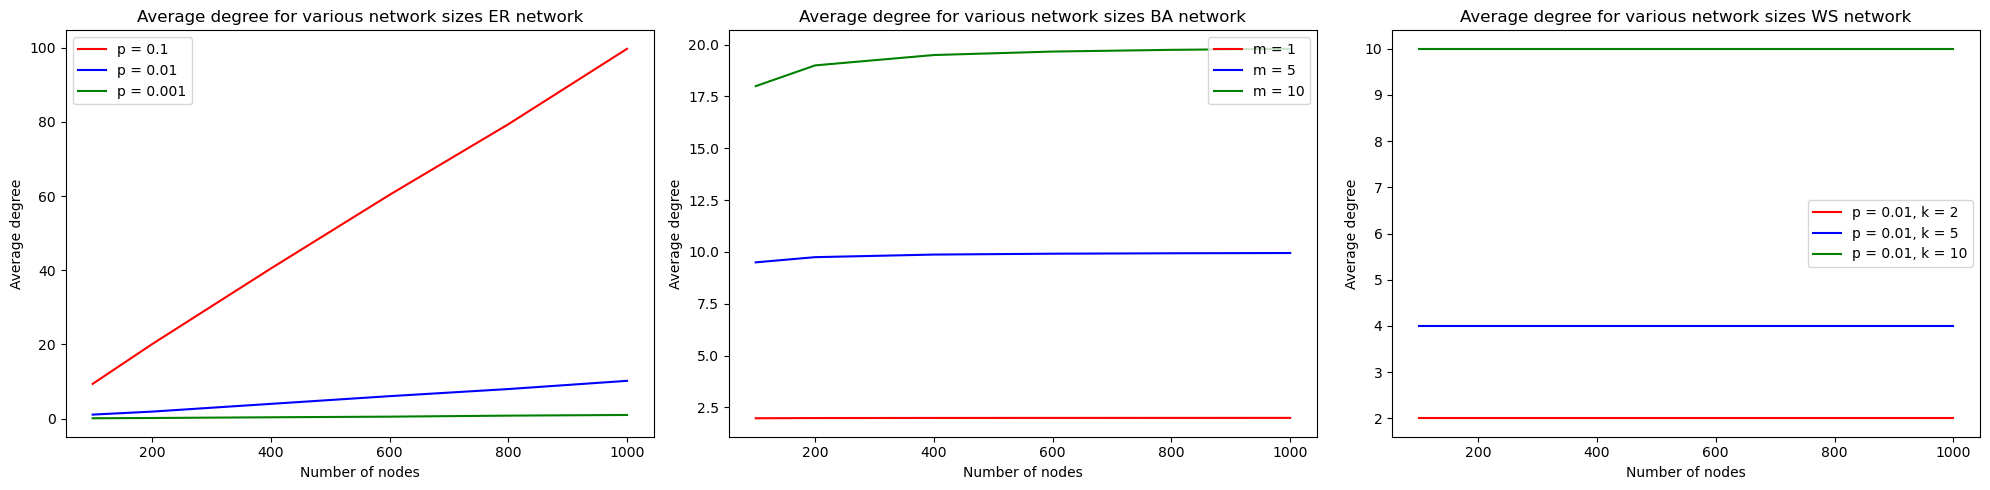

In [263]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
colors = ['red', 'blue', 'green']

for i in range(len(probabilities)):
    # Plot ER
    axs[0].plot(num_nodes, average_degree_er[i], color = colors[i], label = f'p = {probabilities[i]}')
    axs[0].set_xlabel('Number of nodes')
    axs[0].set_ylabel('Average degree')
    axs[0].set_title('Average degree for various network sizes ER network') # TODO: improve
    axs[0].legend()
    
    # Plot BA
    axs[1].plot(num_nodes, average_degree_ba[i], color = colors[i], label = f'm = {num_edges[i]}')
    axs[1].set_xlabel('Number of nodes')
    axs[1].set_ylabel('Average degree')
    axs[1].set_title('Average degree for various network sizes BA network') # TODO: improve
    axs[1].legend()
    
    # Plot WS
    axs[2].plot(num_nodes, average_degree_ws[i], color = colors[i], label = f'p = {p}, k = {num_neighbours[i]}')
    axs[2].set_xlabel('Number of nodes')
    axs[2].set_ylabel('Average degree')
    axs[2].set_title('Average degree for various network sizes WS network') # TODO: improve
    axs[2].legend()

plt.tight_layout()
plt.show()

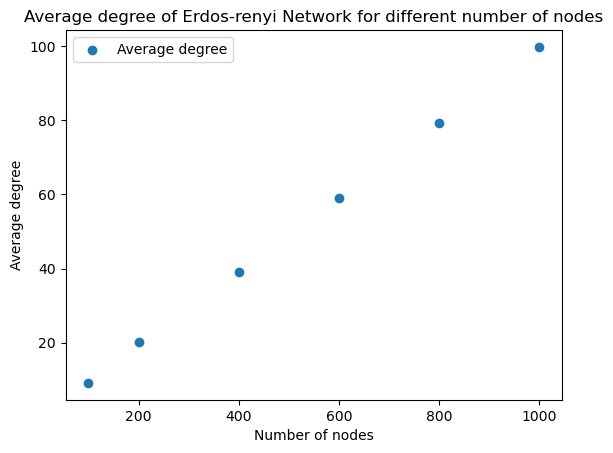

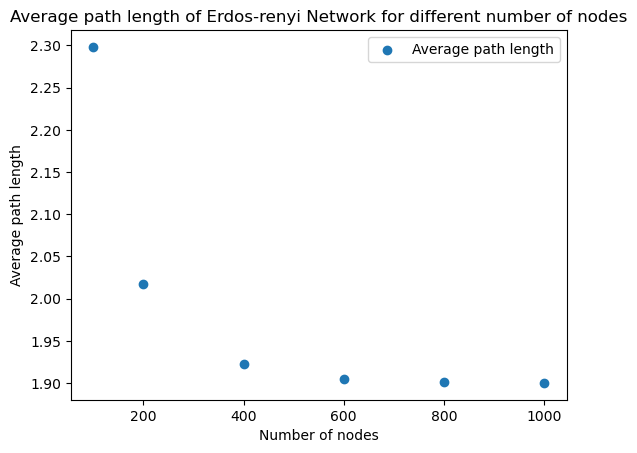

In [181]:
# TESTING PLOT
plt.scatter(num_nodes, average_degree, label=f'Average degree')
    
plt.title(f'Average degree of {network_type.capitalize()} Network for different number of nodes')
plt.xlabel('Number of nodes')
plt.ylabel('Average degree')
plt.legend()
plt.show()

plt.scatter(num_nodes, average_path_length, label=f'Average path length')
    
plt.title(f'Average path length of {network_type.capitalize()} Network for different number of nodes')
plt.xlabel('Number of nodes')
plt.ylabel('Average path length')
plt.legend()
plt.show()

In [ ]:
# TESTING
beta = 1/7
gamma = 1/10
iterations = 100

network = create_network('Erdos-Renyi', 1000, seed = 10, p = 0.005)

trends = run_sir_simulations(network, beta, gamma, initial_infected_nodes = [1,2,3,4,5], iterations = 100, num_simulations = 50)

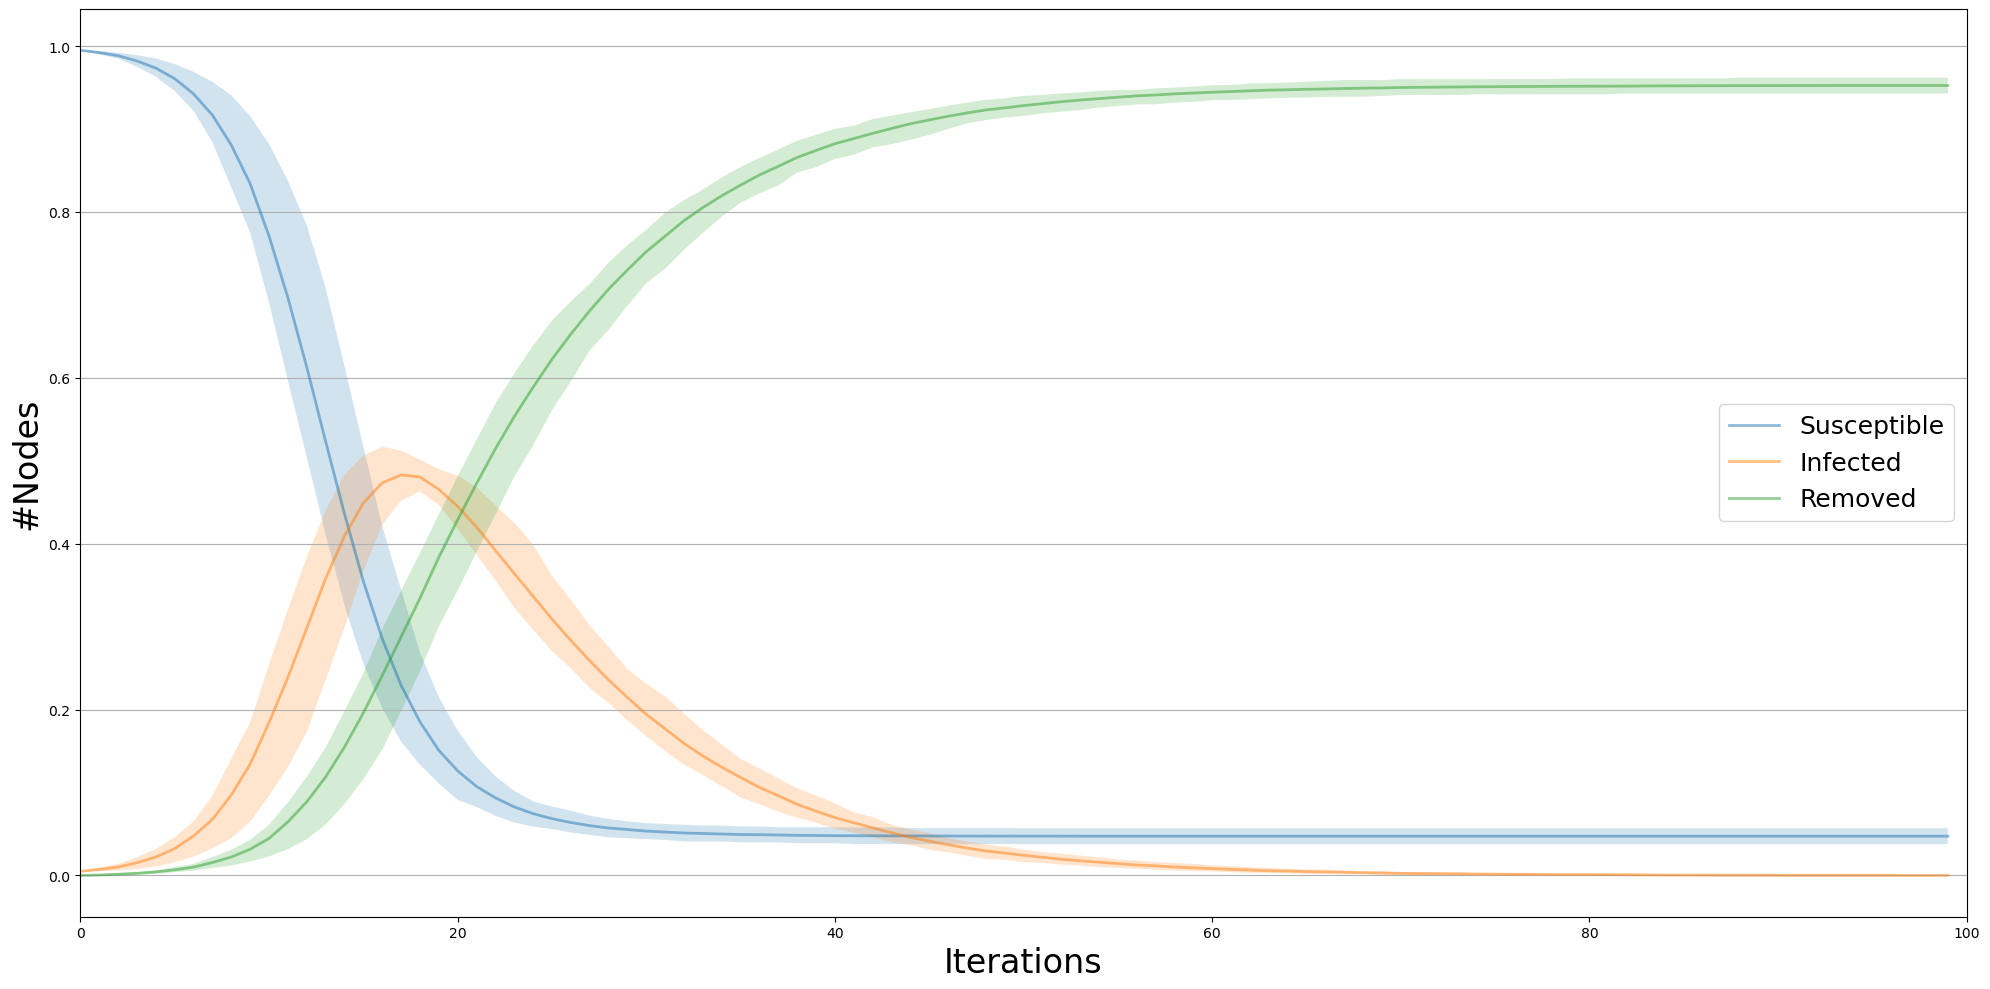

In [91]:
%matplotlib inline
from ndlib.viz.mpl.DiffusionTrend import DiffusionTrend

viz = DiffusionTrend(model, trends)
viz.plot()

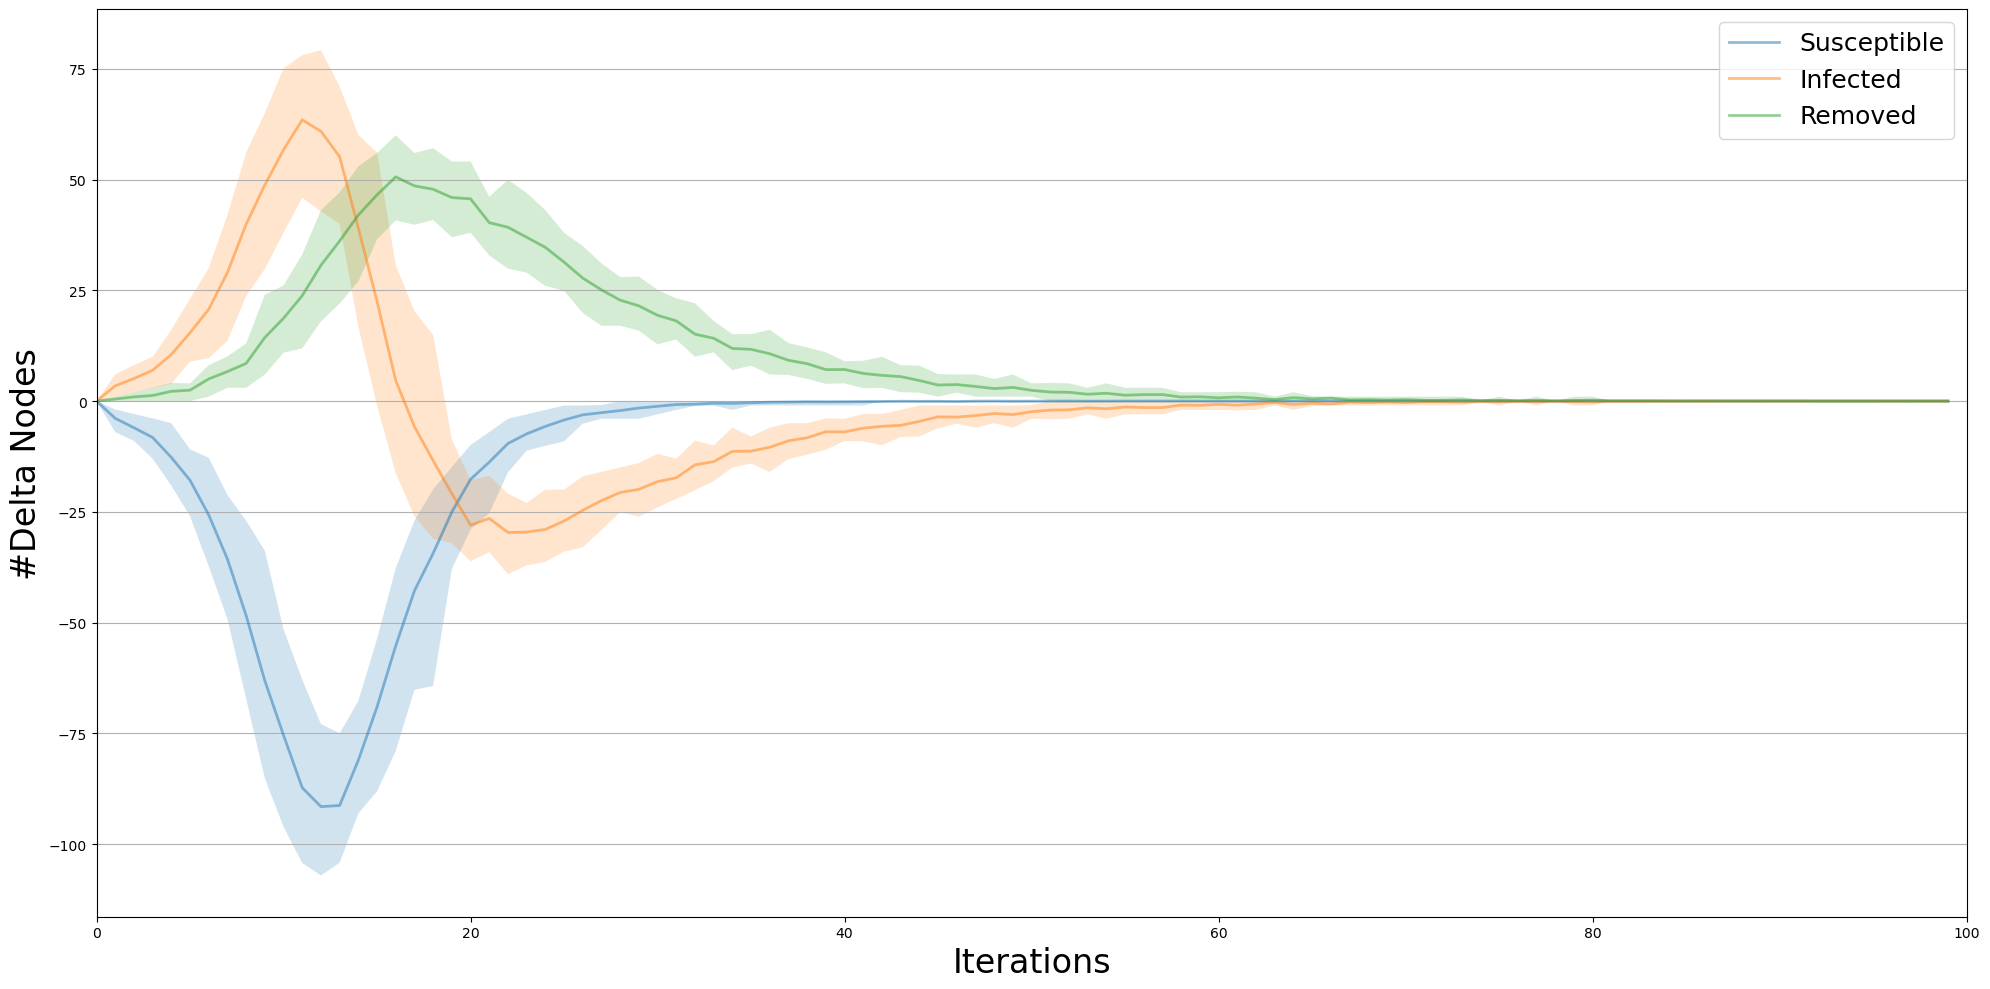

In [75]:
from ndlib.viz.mpl.DiffusionPrevalence import DiffusionPrevalence
viz = DiffusionPrevalence(model, trends)
viz.plot()